In [211]:
#estrarre dati da fifa player csv e utilizzarli

In [212]:
#importiamo le librerie principali
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import missingno as msno
import folium

In [213]:
# lettura ed occhiata ai dati in tabella .csv conn pandas
#mi piace tenere separato i l nome
nomedati='fifa_player_data_set.csv'
#lettura file
raw_data = pd.read_csv(nomedati)
# Creating deep copy of the data
df = raw_data.copy(deep=True)
#controllo vairie info a partire dalle prome cinque righe e info
#df.head(5)
#aggiungo tre colonne
df["goals_per_match"] = df["goals"] / df["matches_played"]
df["goals_per_minute"] = ( df["minutes_played"]/df["goals"])
df["a+g"] = df["assists"] + df["goals"]
#info
df.info()
#Capiamo la shape
# Shape of data
print(f'Shape of data: {df.shape}')



<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   str    
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   str    
 4   club                      2800 non-null   str    
 5   position                  2800 non-null   str    
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_prone       

In [214]:
#pulizia dati, ad esempio sostutuzione di cratteri stringhe con numeri potrebbe fare comodo
# sostituire valori nulli o 0 ed eliminare colonne che non ci interessano 
#print valori nulli anche se dall df.info precedente non ce ne sono 
print(f'somma valori nulli :  \n {df.isna().sum()} ')



somma valori nulli :  
 player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
goals_per_match             3
goals_per_minute            0
a+g                         0
dtype: int64 


In [215]:
#nel caso divisione per zero match minuti sostituisco i valori
df.fillna(0, inplace=True)
#ripeto ciamata per valori nulli
print(f'somma valori nulli :  \n {df.isna().sum()} ')

somma valori nulli :  
 player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
goals_per_match             0
goals_per_minute            0
a+g                         0
dtype: int64 


In [216]:
#controlla giocatori con valori idenici
a = df.player_name.nunique()
print(f'numeri gioctori doppioni : {2800 - a }')

numeri gioctori doppioni : 0


In [217]:
#controllo se ce qualche duplicato
print(f'Somma valori duplicati: \n {df.duplicated().sum()} ')

Somma valori duplicati: 
 0 


In [218]:
# dividi in tabella con valori numerici e co valori stringhe

cat_cols = df.select_dtypes([object, bool]).columns.to_list()
num_cols = df.select_dtypes([int, float]).columns.to_list()
print(f'Categorical features: {cat_cols}')
print(f'Total Categorical features: {len(cat_cols)}')
print('='*110)
print(f'Numerical features: {num_cols}')
print(f'Total Numerical features: {len(num_cols)}')

Categorical features: ['player_name', 'nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']
Total Categorical features: 6
Numerical features: ['player_id', 'age', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left', 'goals_per_match', 'goals_per_minute', 'a+g']
Total Numerical features: 13


/var/folders/ny/37t2ndvn0x5_3d6jd8j1pd8c0000gn/T/ipykernel_3472/3878666655.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes([object, bool]).columns.to_list()


In [219]:
#tabella valori caratteri
df.loc[:, cat_cols]

,player_name,nationality,club,position,injury_prone,transfer_risk_level
0,Player_1,Germany,Liverpool,ST,No,Low
1,Player_2,England,FC Barcelona,ST,No,High
2,Player_3,France,Juventus,RB,No,Medium
3,Player_4,Portugal,Manchester City,LW,Yes,Medium
4,Player_5,Brazil,Liverpool,CDM,No,Low
...,...,...,...,...,...,...
2795,Player_2796,Germany,Bayern Munich,CB,No,Medium
2796,Player_2797,Netherlands,Real Madrid,LB,No,Low
2797,Player_2798,Brazil,Manchester City,ST,No,Medium
2798,Player_2799,Netherlands,Real Madrid,ST,No,Medium


In [220]:
#essendo la la riga il numero stesso del player possiamo rimuovere
cat_cols.remove('player_name')
#controlo se ho eliminat la colonna 
df[cat_cols].head(2)

,nationality,club,position,injury_prone,transfer_risk_level
0,Germany,Liverpool,ST,No,Low
1,England,FC Barcelona,ST,No,High


nationality            8
club                   7
position               9
injury_prone           2
transfer_risk_level    3
dtype: int64


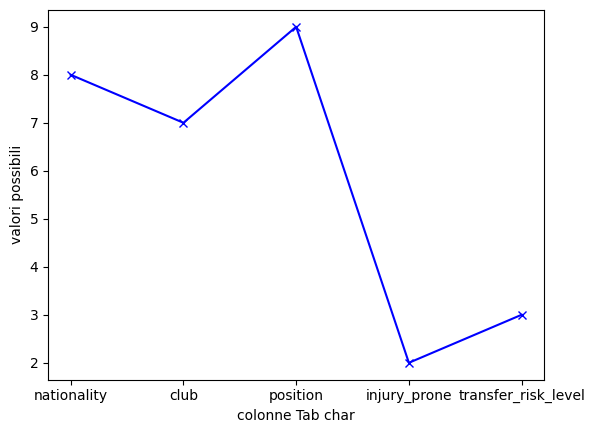

In [221]:
#controllo e grafico valori no unici all interno delel vari categorie 
cardinali = df[cat_cols].nunique()
print(cardinali)

plt.plot(cardinali.index, cardinali.values , color='blue', marker='x')
plt.xlabel('colonne Tab char')
plt.ylabel('valori possibili')
plt.show()
plt.close()

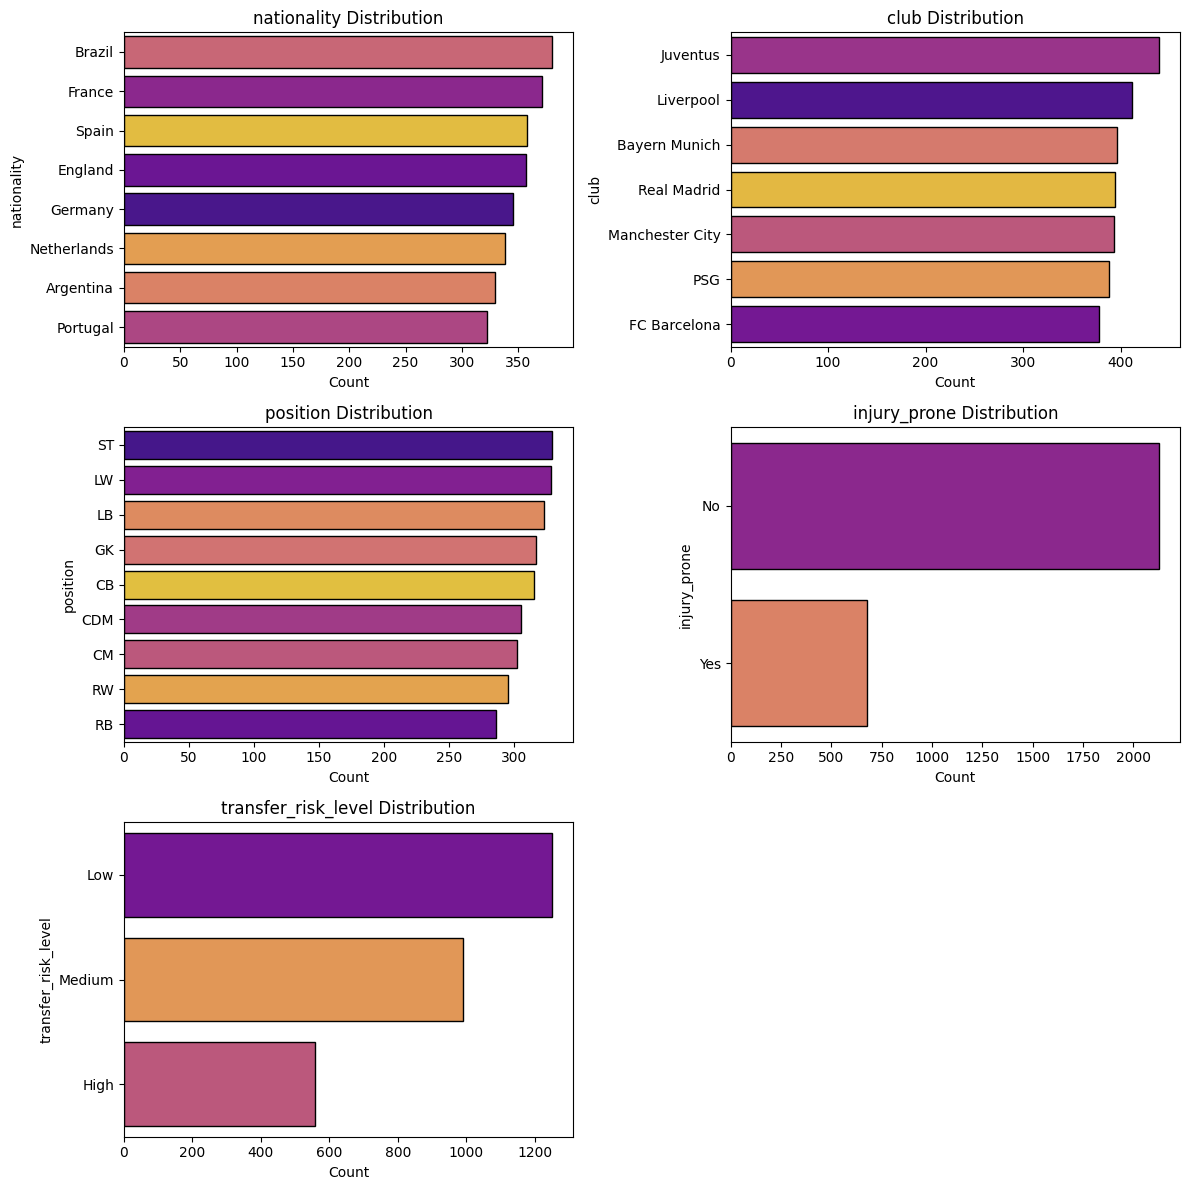

In [222]:
#grafcii per vedere alcune iformazioni iteressanti 

n = len(cat_cols)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[i],
        hue=col,
        legend=False,
        palette='plasma',
        edgecolor='black'
    )

    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Count')   # fixed label
    axes[i].set_ylabel(col)

# Remove unused subplots safely
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [223]:
#analisi della parte numerica
df.loc[:,num_cols]
df[num_cols].head(4)

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,goals_per_match,goals_per_minute,a+g
0,1,23,65,87,8,6,14,2976,122.51,3,0.750000,496.000000,20
1,2,36,90,76,19,3,18,2609,88.47,5,0.157895,869.666667,21
2,3,31,75,91,34,12,15,1158,20.24,3,0.352941,96.500000,27
3,4,27,90,86,35,18,13,145,164.29,0,0.514286,8.055556,31


In [224]:
#rimuoviamo ridondandi come pleyer id
num_cols.remove('player_id')
df[num_cols].describe()

/Users/michele/esercizi_collo/.data/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/michele/esercizi_collo/.data/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,goals_per_match,goals_per_minute,a+g
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857,inf,inf,31.276786
std,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445,NaN,NaN,13.749617
min,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000,0.333333,58.053571,21.000000
50%,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000,0.712912,116.207373,31.000000
75%,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000,1.500000,246.212500,42.000000
max,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000,inf,inf,63.000000


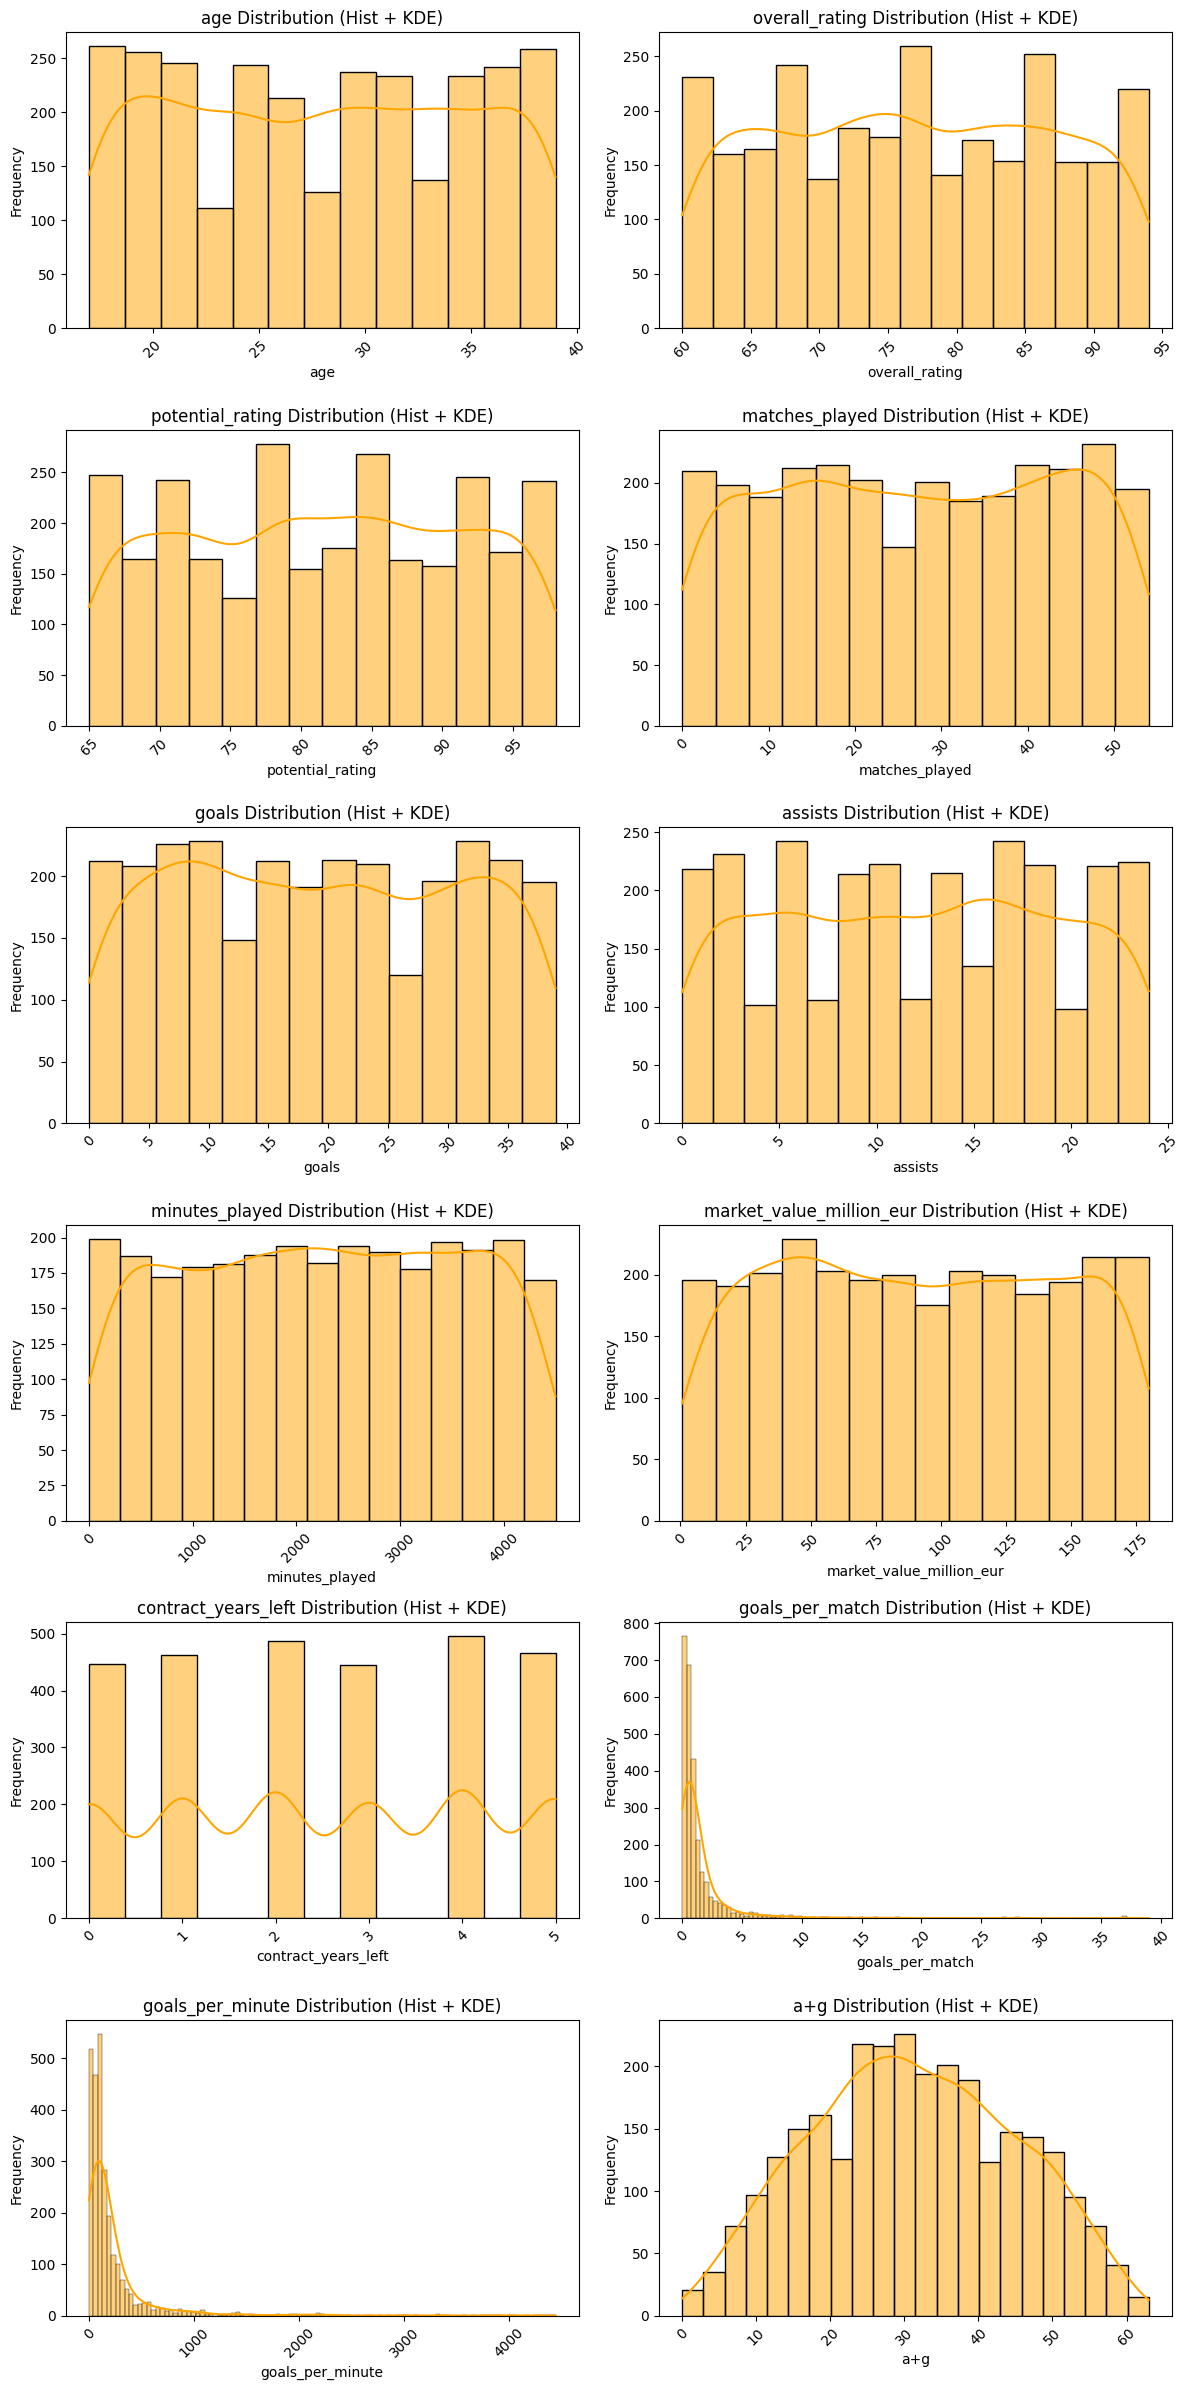

In [225]:
# istogrammi

n = len(num_cols)
cols = 2
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i],
        color='orange',
        edgecolor='black'
    )

    axes[i].set_title(f'{col} Distribution (Hist + KDE)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

# rimuovi i plot 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [226]:
#ora andiamo a vedere come cambiano le cose per posizione
df[cat_cols].head()

,nationality,club,position,injury_prone,transfer_risk_level
0,Germany,Liverpool,ST,No,Low
1,England,FC Barcelona,ST,No,High
2,France,Juventus,RB,No,Medium
3,Portugal,Manchester City,LW,Yes,Medium
4,Brazil,Liverpool,CDM,No,Low


In [227]:
# cerco relazione tra posizioen e infortuni fa tutto crosstab
ct = pd.crosstab(
    index=df['injury_prone'],
    columns=df['position'],
    margins=False,
    normalize=False
)

ct.head(3)

position,CB,CDM,CM,GK,LB,LW,RB,RW,ST
injury_prone,,,,,,,,,
No,234,225,227,245,247,256,209,234,248
Yes,81,80,75,72,76,72,77,61,81


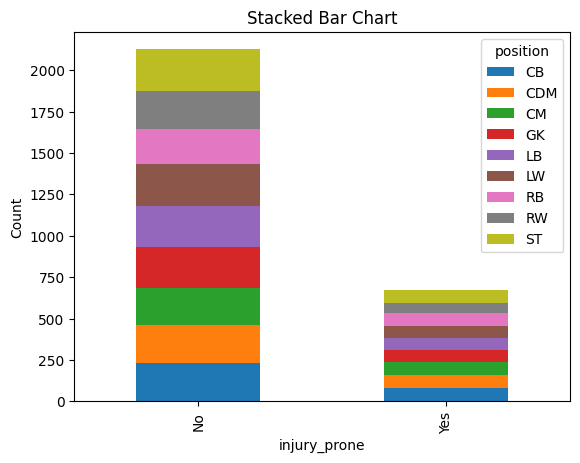

In [228]:
# grafica la quantida di giocatori injury prone e non per ruolo
ct.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart")
plt.ylabel("Count")
plt.show()

In [229]:

# Relation between club x transfer_risk_level

ct = pd.crosstab(
    index=df['club'],
    columns=df['transfer_risk_level'],
    margins=False,
    normalize=False
)

ct.head(3)

transfer_risk_level,High,Low,Medium
club,,,
Bayern Munich,83,181,132
FC Barcelona,93,153,132
Juventus,92,189,158


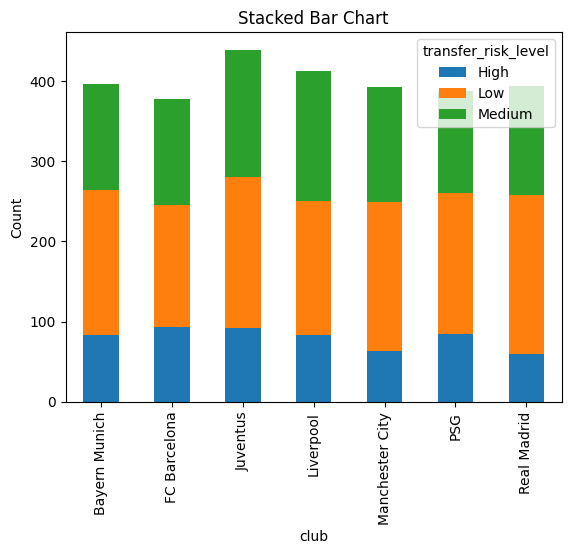

In [230]:
# rischo rasferimento per squadra
ct.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart")
plt.ylabel("Count")
plt.show()

In [231]:
#rischio trasferimento per posizione
ct = pd.crosstab(
    index=df['position'],
    columns=df['transfer_risk_level'],
    margins=False,
    normalize=False
)
ct.head() 

transfer_risk_level,High,Low,Medium
position,,,
CB,69,147,99
CDM,57,146,102
CM,53,134,115
GK,52,158,107
LB,78,138,107


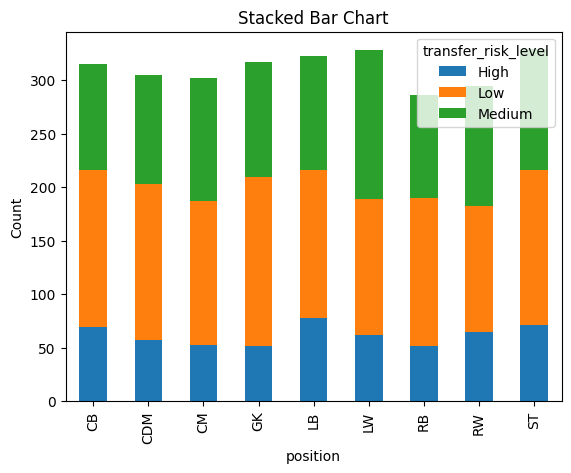

In [232]:
# rischo rasferimento per sposizione
ct.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart")
plt.ylabel("Count")
plt.show()

In [233]:
df[num_cols].head(5)

,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,goals_per_match,goals_per_minute,a+g
0,23,65,87,8,6,14,2976,122.51,3,0.750000,496.000000,20
1,36,90,76,19,3,18,2609,88.47,5,0.157895,869.666667,21
2,31,75,91,34,12,15,1158,20.24,3,0.352941,96.500000,27
3,27,90,86,35,18,13,145,164.29,0,0.514286,8.055556,31
4,24,84,96,41,6,6,2226,121.34,4,0.146341,371.000000,12


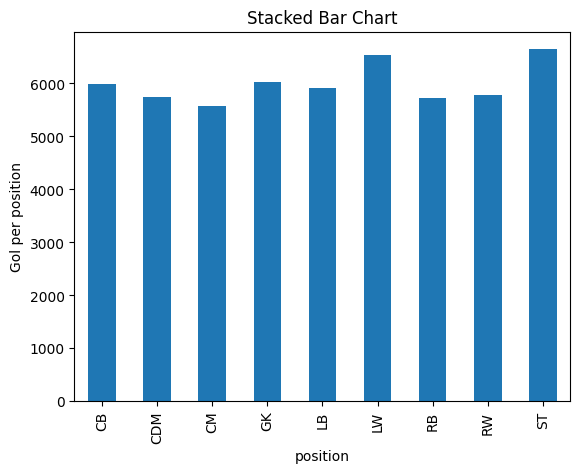

In [234]:
ct = df.groupby('position')['goals'].sum()
ct.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart")
plt.ylabel("Gol per position")
plt.show()

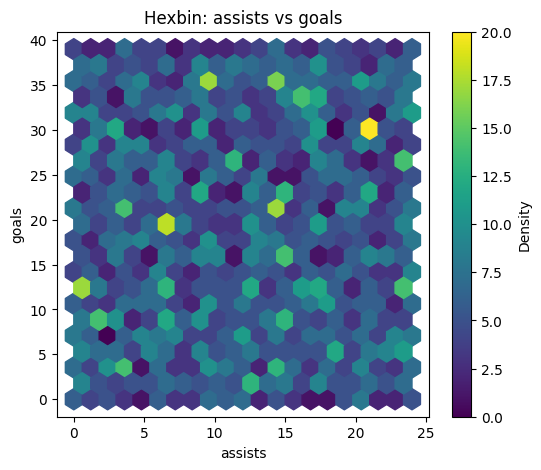

In [235]:
#gol e assist 
plt.figure(figsize=(6,5))

plt.hexbin(
    df['assists'],
    df['goals'],
    gridsize=20,
    cmap='viridis'
)

plt.colorbar(label='Density')
plt.xlabel('assists')
plt.ylabel('goals')
plt.title('Hexbin: assists vs goals')

plt.show()

/var/folders/ny/37t2ndvn0x5_3d6jd8j1pd8c0000gn/T/ipykernel_3472/2713106378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ny/37t2ndvn0x5_3d6jd8j1pd8c0000gn/T/ipykernel_3472/2713106378.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


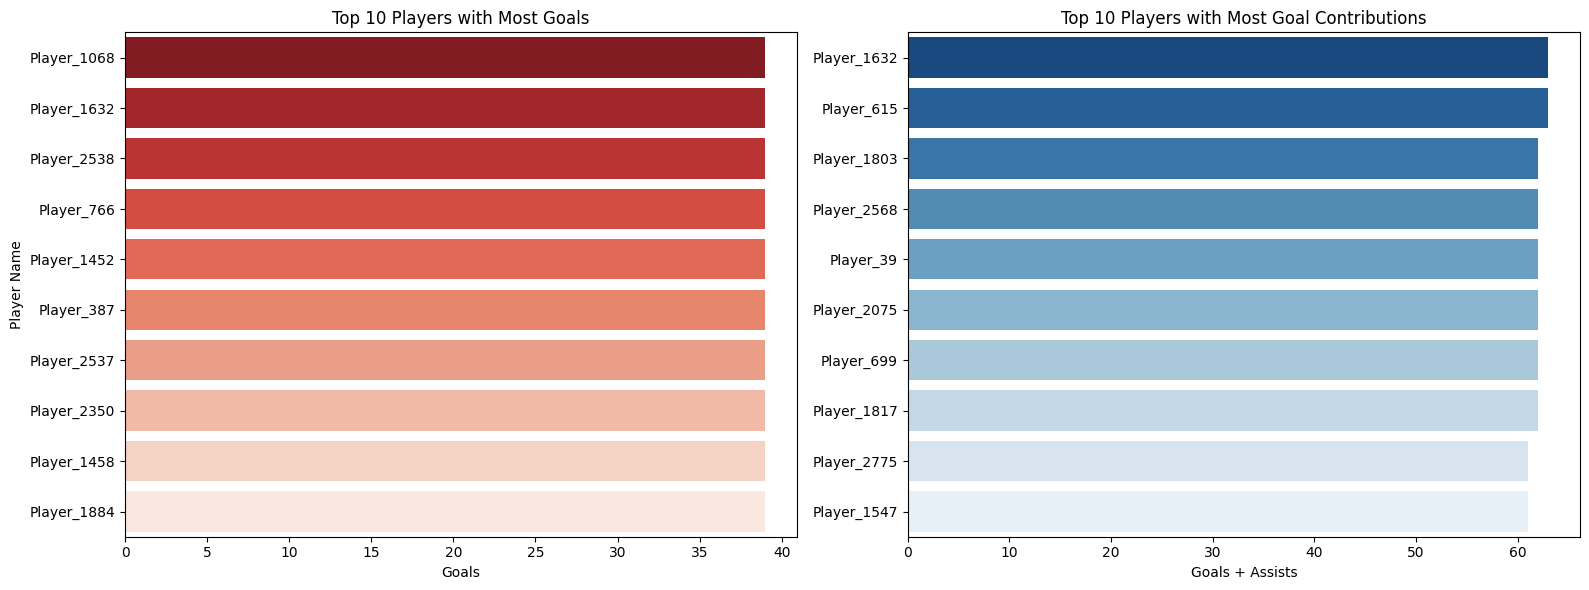

In [242]:
top_goals = df.sort_values(by='goals', ascending=False).head(10)
top_contribution = df.sort_values(by='a+g', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_goals,
    x='goals',
    y='player_name',
    palette='Reds_r',
    ax=axes[0]
)
axes[0].set_title('Top 10 Players with Most Goals')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Player Name')

sns.barplot(
    data=top_contrib,
    x='a+g',
    y='player_name',
    palette='Blues_r',
    ax=axes[1]
)
axes[1].set_title('Top 10 Players with Most Goal Contributions')
axes[1].set_xlabel('Goals + Assists')
axes[1].set_ylabel('')  # inutile ripetere

plt.tight_layout()
plt.show()